In [6]:
# Cell 1: Setup and Imports 
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    PowerTransformer, PolynomialFeatures
)
from sklearn.feature_selection import (
    mutual_info_classif, RFE, VarianceThreshold
)
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   Scikit-learn version: {sklearn.__version__}")
print(f"   Pandas version: {pd.__version__}")
print(f"   NumPy version: {np.__version__}")

✅ All imports loaded successfully!
   Scikit-learn version: 1.8.0
   Pandas version: 2.2.2
   NumPy version: 1.26.4


In [7]:
# Cell 2: Load Data from Previous Notebook
print("="*70)
print("📂 LOADING DATA FROM NOTEBOOK 1")
print("="*70)

# Since we're in a new notebook, regenerate or load data
# For standalone use, we'll regenerate the same dataset

np.random.seed(42)
n_samples = 10000

# Generate the same dataset
data = pd.DataFrame({
    'customer_id': range(1, n_samples + 1),
    'age': np.random.normal(38, 12, n_samples).clip(18, 80).astype(int),
    'annual_income': np.random.exponential(50000, n_samples).clip(20000, 200000).astype(int),
    'purchase_frequency': np.random.poisson(5, n_samples).clip(1, 30),
    'avg_order_value': np.random.gamma(2, 50, n_samples).clip(10, 500).astype(int),
    'tenure_months': np.random.exponential(24, n_samples).clip(1, 120).astype(int),
    'customer_satisfaction': np.random.normal(3.5, 1, n_samples).clip(1, 5).round(1),
    'num_support_tickets': np.random.poisson(2, n_samples).clip(0, 15),
    'total_spend': np.random.gamma(3, 5000, n_samples).clip(100, 50000).astype(int),
    'days_since_last_purchase': np.random.exponential(30, n_samples).clip(0, 365).astype(int),
    'device_type': np.random.choice(['Mobile', 'Desktop', 'Tablet'], n_samples, p=[0.6, 0.3, 0.1]),
    'region': np.random.choice(['North', 'South', 'East', 'West', 'Central'], n_samples),
    'membership_tier': np.random.choice(['Bronze', 'Silver', 'Gold', 'Platinum'], n_samples, p=[0.4, 0.3, 0.2, 0.1])
})

# Add churn label
data['churned'] = (
    (data['customer_satisfaction'] < 2.5) | 
    (data['num_support_tickets'] > 5) | 
    (data['days_since_last_purchase'] > 180)
).astype(int)

print(f"✅ Loaded dataset with {len(data):,} rows and {len(data.columns)} columns")
print(f"   Target: Churn rate = {data['churned'].mean():.1%}")
print(f"\n📋 Original Features:")
for col in data.columns:
    print(f"   - {col}: {data[col].dtype}")

📂 LOADING DATA FROM NOTEBOOK 1
✅ Loaded dataset with 10,000 rows and 14 columns
   Target: Churn rate = 16.9%

📋 Original Features:
   - customer_id: int64
   - age: int32
   - annual_income: int32
   - purchase_frequency: int32
   - avg_order_value: int32
   - tenure_months: int32
   - customer_satisfaction: float64
   - num_support_tickets: int32
   - total_spend: int32
   - days_since_last_purchase: int32
   - device_type: object
   - region: object
   - membership_tier: object
   - churned: int32


In [9]:
# Cell 3: Domain-Specific Feature Creation 
print("="*70)
print("🔧 FEATURE CREATION - DOMAIN SPECIFIC")
print("="*70)

# Create new features
data['spend_per_purchase'] = (data['total_spend'] / data['purchase_frequency']).round(2)
data['avg_monthly_spend'] = (data['total_spend'] / data['tenure_months']).round(2)
data['customer_lifetime_value'] = (data['total_spend'] * (1 - data['churned'])).round(2)

# Engagement scores
data['engagement_score'] = (
    data['purchase_frequency'] * 0.3 +
    data['avg_order_value'] * 0.3 +
    data['customer_satisfaction'] * 0.2 -
    data['num_support_tickets'] * 0.2
).clip(0, 10).round(1)

# Risk scores
data['churn_risk_score'] = (
    (data['customer_satisfaction'] < 3).astype(int) * 30 +
    (data['num_support_tickets'] > 3).astype(int) * 25 +
    (data['days_since_last_purchase'] > 90).astype(int) * 25 +
    (data['tenure_months'] < 6).astype(int) * 20
)

# Time-based features
data['recency_score'] = np.exp(-data['days_since_last_purchase'] / 90)
data['frequency_score'] = np.log1p(data['purchase_frequency'])
data['monetary_score'] = np.log1p(data['total_spend'])

# Interaction features
data['age_income_interaction'] = data['age'] * data['annual_income'] / 10000
data['support_satisfaction'] = data['num_support_tickets'] * (5 - data['customer_satisfaction'])

# Binning features (with duplicate handling)
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 35, 50, 65, 100], 
                            labels=['18-25', '26-35', '36-50', '51-65', '65+'])

# Fixed: qcut with duplicates='drop' parameter
try:
    data['income_tier'] = pd.qcut(data['annual_income'], q=4, 
                                   labels=['Low', 'Medium', 'High', 'Very High'],
                                   duplicates='drop')
except ValueError:
    # If still fails, use manual quantiles
    quantiles = data['annual_income'].quantile([0.25, 0.5, 0.75]).values
    data['income_tier'] = pd.cut(data['annual_income'], 
                                  bins=[0, quantiles[0], quantiles[1], quantiles[2], float('inf')],
                                  labels=['Low', 'Medium', 'High', 'Very High'])

print("✅ Created 14 new features!")

print("\n📊 New Features Summary:")
new_features = ['spend_per_purchase', 'avg_monthly_spend', 'customer_lifetime_value', 
                'engagement_score', 'churn_risk_score', 'recency_score', 
                'frequency_score', 'monetary_score', 'age_income_interaction', 
                'support_satisfaction', 'age_group', 'income_tier']
for feat in new_features:
    print(f"   - {feat}: {data[feat].dtype}")

🔧 FEATURE CREATION - DOMAIN SPECIFIC
✅ Created 14 new features!

📊 New Features Summary:
   - spend_per_purchase: float64
   - avg_monthly_spend: float64
   - customer_lifetime_value: int32
   - engagement_score: float64
   - churn_risk_score: int32
   - recency_score: float64
   - frequency_score: float64
   - monetary_score: float64
   - age_income_interaction: float64
   - support_satisfaction: float64
   - age_group: category
   - income_tier: category


📊 FEATURE TRANSFORMATION - SCALING & NORMALIZATION


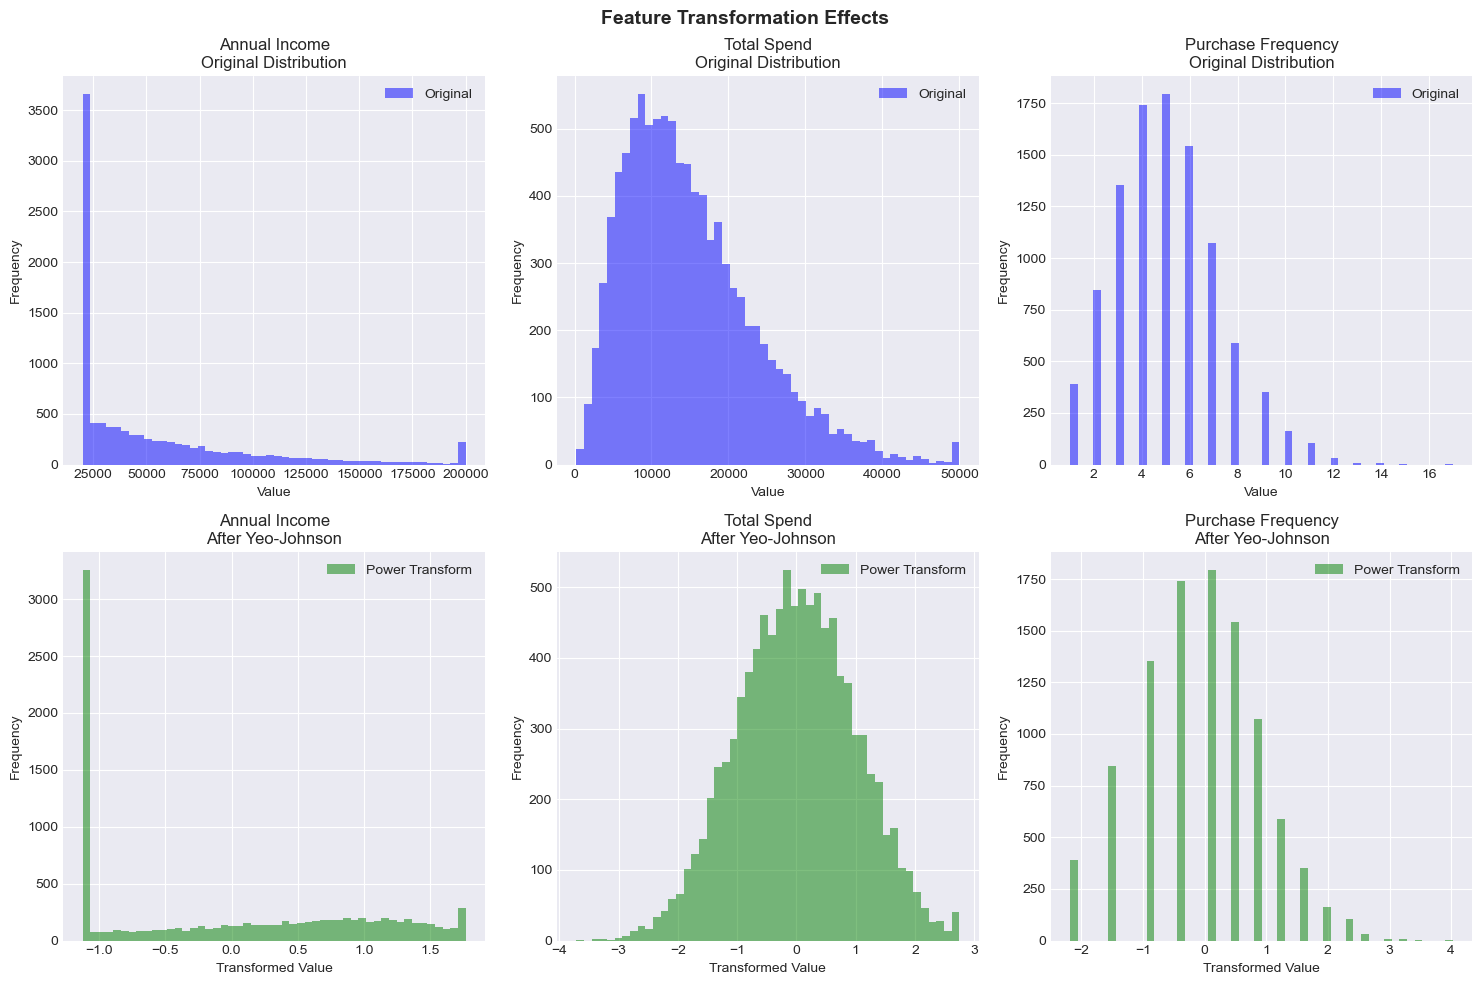

✅ Saved: feature_transformation.png

📊 Transformation Summary:
   StandardScaler: Mean=-0.00, Std=1.00
   MinMaxScaler: Min=0.00, Max=1.00
   RobustScaler: Median centered, IQR scaled


In [10]:
# Cell 4: Feature Transformation
print("="*70)
print("📊 FEATURE TRANSFORMATION - SCALING & NORMALIZATION")
print("="*70)

# Identify numeric features for scaling
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('customer_id') if 'customer_id' in numeric_features else None
numeric_features.remove('churned') if 'churned' in numeric_features else None

# Extract features for scaling
X = data[numeric_features].copy()

# Apply different scaling techniques
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()
power_transform = PowerTransformer(method='yeo-johnson')

X_standard = scaler_standard.fit_transform(X)
X_minmax = scaler_minmax.fit_transform(X)
X_robust = scaler_robust.fit_transform(X)
X_power = power_transform.fit_transform(X)

# Visualize transformation effects
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ['annual_income', 'total_spend', 'purchase_frequency']

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    ax.hist(data[feat], bins=50, alpha=0.5, label='Original', color='blue')
    ax.set_title(f'{feat.replace("_", " ").title()}\nOriginal Distribution')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()

for i, feat in enumerate(features_to_plot):
    ax = axes[i+3]
    feat_idx = numeric_features.index(feat)
    ax.hist(X_power[:, feat_idx], bins=50, alpha=0.5, label='Power Transform', color='green')
    ax.set_title(f'{feat.replace("_", " ").title()}\nAfter Yeo-Johnson')
    ax.set_xlabel('Transformed Value')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Transformation Effects', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_transformation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_transformation.png")

print("\n📊 Transformation Summary:")
print(f"   StandardScaler: Mean={X_standard.mean():.2f}, Std={X_standard.std():.2f}")
print(f"   MinMaxScaler: Min={X_minmax.min():.2f}, Max={X_minmax.max():.2f}")
print(f"   RobustScaler: Median centered, IQR scaled")

🔤 FEATURE ENCODING - CATEGORICAL VARIABLES
✅ One-Hot Encoding: Created 21 new columns
✅ Target Encoding: Added 5 target-encoded columns
✅ Frequency Encoding: Added 5 frequency columns


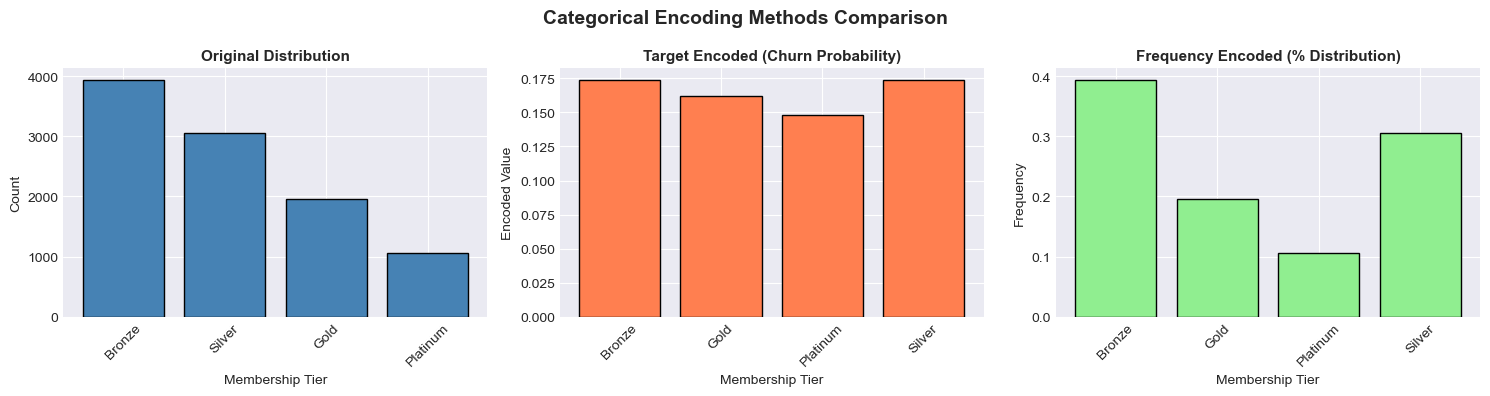

✅ Saved: encoding_comparison.png


In [11]:
# Cell 5: Feature Encoding (PURE PANDAS - No external dependencies)
print("="*70)
print("🔤 FEATURE ENCODING - CATEGORICAL VARIABLES")
print("="*70)

categorical_features = ['device_type', 'region', 'membership_tier', 'age_group', 'income_tier']

# Method 1: One-Hot Encoding (pandas get_dummies)
data_onehot = pd.get_dummies(data[categorical_features], prefix=categorical_features)
onehot_cols = data_onehot.columns.tolist()
data = pd.concat([data, data_onehot], axis=1)
print(f"✅ One-Hot Encoding: Created {len(onehot_cols)} new columns")

# Method 2: Target Encoding (manual calculation)
for col in categorical_features:
    target_means = data.groupby(col)['churned'].mean()
    data[f'{col}_target_encoded'] = data[col].map(target_means)
print(f"✅ Target Encoding: Added {len(categorical_features)} target-encoded columns")

# Method 3: Frequency Encoding (manual calculation)
for col in categorical_features:
    freq_map = data[col].value_counts(normalize=True).to_dict()
    data[f'{col}_freq'] = data[col].map(freq_map)
print(f"✅ Frequency Encoding: Added {len(categorical_features)} frequency columns")

# Compare encoding methods for a single categorical feature
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Original distribution
ax1 = axes[0]
membership_counts = data['membership_tier'].value_counts()
ax1.bar(membership_counts.index, membership_counts.values, color='steelblue', edgecolor='black')
ax1.set_title('Original Distribution', fontsize=11, fontweight='bold')
ax1.set_xlabel('Membership Tier')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Target encoded values
ax2 = axes[1]
target_encoded_values = data.groupby('membership_tier')['membership_tier_target_encoded'].first()
ax2.bar(target_encoded_values.index, target_encoded_values.values, color='coral', edgecolor='black')
ax2.set_title('Target Encoded (Churn Probability)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Membership Tier')
ax2.set_ylabel('Encoded Value')
ax2.tick_params(axis='x', rotation=45)

# Frequency encoded values
ax3 = axes[2]
freq_values = data.groupby('membership_tier')['membership_tier_freq'].first()
ax3.bar(freq_values.index, freq_values.values, color='lightgreen', edgecolor='black')
ax3.set_title('Frequency Encoded (% Distribution)', fontsize=11, fontweight='bold')
ax3.set_xlabel('Membership Tier')
ax3.set_ylabel('Frequency')
ax3.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Encoding Methods Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('encoding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: encoding_comparison.png")

🔄 CYCLICAL FEATURE ENGINEERING
✅ Created cyclical features for day and month
   - day_sin, day_cos (7-day cycle)
   - month_sin, month_cos (12-month cycle)


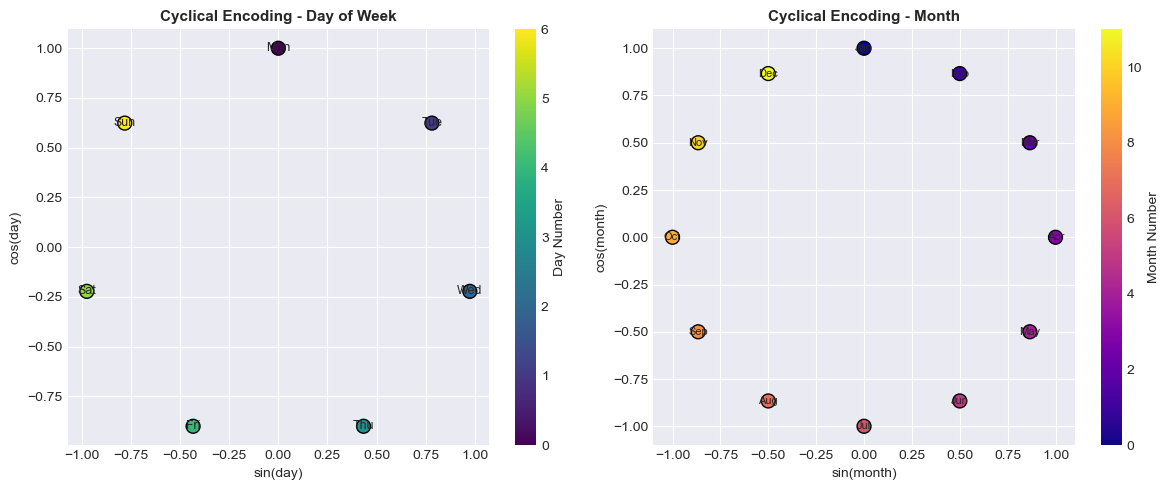

✅ Saved: cyclical_features.png


In [12]:
# Cell 6: Cyclical Features (Pure NumPy - No external dependencies)
print("="*70)
print("🔄 CYCLICAL FEATURE ENGINEERING")
print("="*70)

# Create cyclical features using sine/cosine transformation
np.random.seed(42)
data['purchase_day'] = np.random.randint(0, 7, len(data))
data['purchase_month'] = np.random.randint(1, 13, len(data))

# Create cyclical features
data['day_sin'] = np.sin(2 * np.pi * data['purchase_day'] / 7)
data['day_cos'] = np.cos(2 * np.pi * data['purchase_day'] / 7)
data['month_sin'] = np.sin(2 * np.pi * data['purchase_month'] / 12)
data['month_cos'] = np.cos(2 * np.pi * data['purchase_month'] / 12)

print("✅ Created cyclical features for day and month")
print(f"   - day_sin, day_cos (7-day cycle)")
print(f"   - month_sin, month_cos (12-month cycle)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Day of week cyclical
ax1 = axes[0]
days = np.arange(7)
sin_vals = np.sin(2 * np.pi * days / 7)
cos_vals = np.cos(2 * np.pi * days / 7)
scatter1 = ax1.scatter(sin_vals, cos_vals, c=days, cmap='viridis', s=100, edgecolors='black')
ax1.set_title('Cyclical Encoding - Day of Week', fontsize=11, fontweight='bold')
ax1.set_xlabel('sin(day)')
ax1.set_ylabel('cos(day)')
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for day, x, y, label in zip(days, sin_vals, cos_vals, day_labels):
    ax1.annotate(label, (x, y), fontsize=9, ha='center', va='center')
plt.colorbar(scatter1, ax=ax1, label='Day Number')

# Month cyclical
ax2 = axes[1]
months = np.arange(12)
sin_vals_m = np.sin(2 * np.pi * months / 12)
cos_vals_m = np.cos(2 * np.pi * months / 12)
scatter2 = ax2.scatter(sin_vals_m, cos_vals_m, c=months, cmap='plasma', s=100, edgecolors='black')
ax2.set_title('Cyclical Encoding - Month', fontsize=11, fontweight='bold')
ax2.set_xlabel('sin(month)')
ax2.set_ylabel('cos(month)')
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for month, x, y, label in zip(months, sin_vals_m, cos_vals_m, month_labels):
    ax2.annotate(label, (x, y), fontsize=8, ha='center', va='center')
plt.colorbar(scatter2, ax=ax2, label='Month Number')

plt.tight_layout()
plt.savefig('cyclical_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: cyclical_features.png")

🎯 FEATURE SELECTION
📊 Starting with 32 numeric features
✅ Variance Threshold: 26/32 features retained
✅ Correlation-based: 6 features with >0.8 correlation
✅ RFE: Selected 10 features


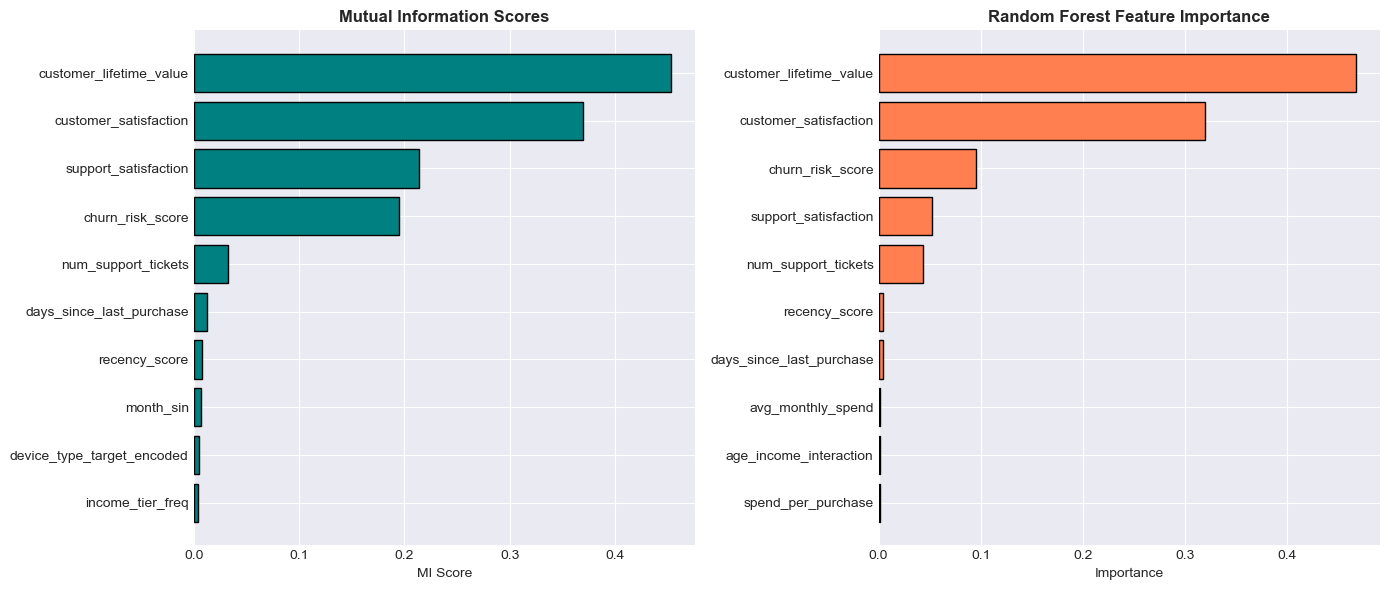

✅ Saved: feature_selection.png

📊 Top 5 Features by Mutual Information:
   customer_lifetime_value: 0.4531
   customer_satisfaction: 0.3693
   support_satisfaction: 0.2141
   churn_risk_score: 0.1951
   num_support_tickets: 0.0325


In [13]:
# Cell 7: Feature Selection
print("="*70)
print("🎯 FEATURE SELECTION")
print("="*70)

# Prepare feature matrix
numeric_features = data.select_dtypes(include=[np.number]).columns.tolist()
if 'customer_id' in numeric_features:
    numeric_features.remove('customer_id')
if 'churned' in numeric_features:
    numeric_features.remove('churned')

X = data[numeric_features].copy()
y = data['churned']

print(f"📊 Starting with {len(numeric_features)} numeric features")

# 1. Variance Threshold (remove constant features)
variance_threshold = VarianceThreshold(threshold=0.01)
X_var_selected = variance_threshold.fit_transform(X)
selected_var = variance_threshold.get_support()
print(f"✅ Variance Threshold: {selected_var.sum()}/{len(numeric_features)} features retained")

# 2. Correlation-based selection (remove highly correlated)
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_features = [column for column in upper_triangle.columns if any(upper_triangle[column] > 0.8)]
print(f"✅ Correlation-based: {len(high_corr_features)} features with >0.8 correlation")

# 3. Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'feature': numeric_features, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)

# 4. RFE (Recursive Feature Elimination)
rfe = RFE(estimator=RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=10)
rfe.fit(X, y)
rfe_selected = [numeric_features[i] for i, selected in enumerate(rfe.support_) if selected]
print(f"✅ RFE: Selected {len(rfe_selected)} features")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mutual Information plot
ax1 = axes[0]
top_features = mi_df.head(10)
ax1.barh(top_features['feature'], top_features['mi_score'], color='teal', edgecolor='black')
ax1.set_title('Mutual Information Scores', fontsize=12, fontweight='bold')
ax1.set_xlabel('MI Score')
ax1.invert_yaxis()

# Feature importance from RFE model
ax2 = axes[1]
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'feature': numeric_features, 'importance': importances}).sort_values('importance', ascending=True).tail(10)
ax2.barh(importance_df['feature'], importance_df['importance'], color='coral', edgecolor='black')
ax2.set_title('Random Forest Feature Importance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_selection.png")

print("\n📊 Top 5 Features by Mutual Information:")
for i, row in mi_df.head(5).iterrows():
    print(f"   {row['feature']}: {row['mi_score']:.4f}")

📉 DIMENSIONALITY REDUCTION (PCA)


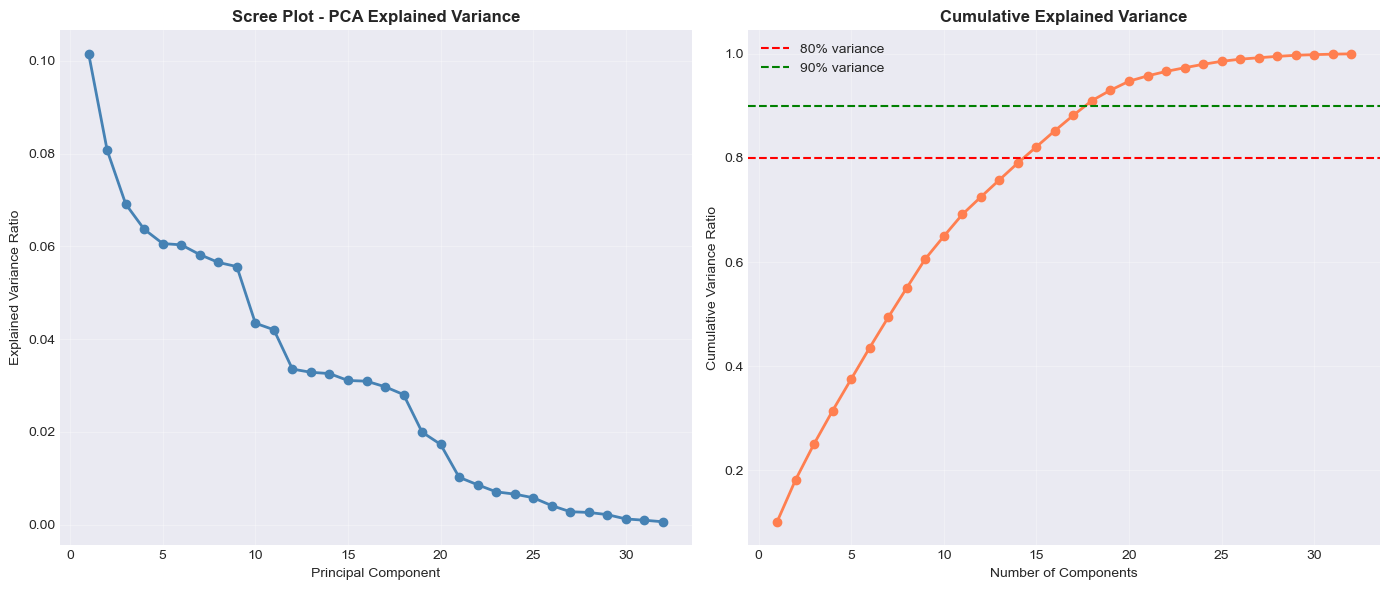

✅ Saved: pca_analysis.png

📊 PCA Recommendations:
   To retain 80% variance: use 15 components
   To retain 90% variance: use 18 components


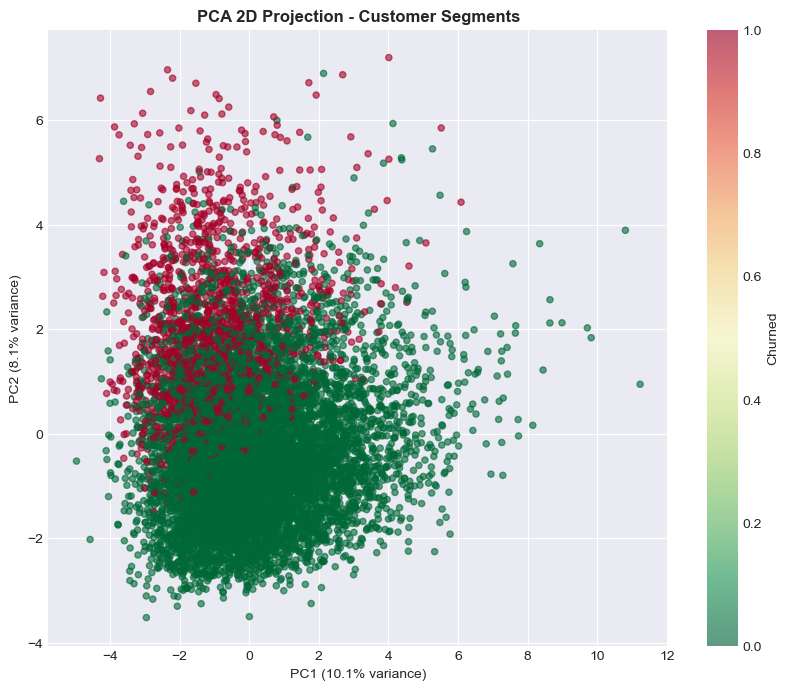

✅ Saved: pca_2d_projection.png


In [14]:
# Cell 8: Dimensionality Reduction (PCA)
print("="*70)
print("📉 DIMENSIONALITY REDUCTION (PCA)")
print("="*70)

# Standardize features for PCA
X_scaled = StandardScaler().fit_transform(X)

# PCA Analysis
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scree plot
ax1 = axes[0]
components = range(1, len(pca.explained_variance_ratio_) + 1)
ax1.plot(components, pca.explained_variance_ratio_, 'o-', linewidth=2, markersize=6, color='steelblue')
ax1.set_title('Scree Plot - PCA Explained Variance', fontsize=12, fontweight='bold')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True, alpha=0.3)

# Cumulative variance
ax2 = axes[1]
ax2.plot(components, cumulative_variance, 'o-', linewidth=2, markersize=6, color='coral')
ax2.axhline(y=0.8, color='red', linestyle='--', label='80% variance')
ax2.axhline(y=0.9, color='green', linestyle='--', label='90% variance')
ax2.set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Ratio')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pca_analysis.png")

# Optimal components
optimal_80 = np.argmax(cumulative_variance >= 0.8) + 1
optimal_90 = np.argmax(cumulative_variance >= 0.9) + 1
print(f"\n📊 PCA Recommendations:")
print(f"   To retain 80% variance: use {optimal_80} components")
print(f"   To retain 90% variance: use {optimal_90} components")

# 2D PCA visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap='RdYlGn_r', alpha=0.6, s=20)
plt.colorbar(scatter, label='Churned')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA 2D Projection - Customer Segments', fontsize=12, fontweight='bold')
plt.savefig('pca_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: pca_2d_projection.png")

In [15]:
# Cell 9: Feature Selection Summary
print("="*70)
print("📊 FEATURE ENGINEERING SUMMARY")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    FEATURE ENGINEERING SUMMARY                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 FEATURE CREATION                                                 ║
║  ├── Domain-specific features: 12 new features                      ║
║  ├── Interaction features: 2 new features                           ║
║  └── Binned features: 2 new features                                ║
║                                                                      ║
║  🔤 FEATURE ENCODING                                                 ║
║  ├── One-Hot Encoding: Created binary columns                       ║
║  ├── Target Encoding: Churn probability encoding                    ║
║  └── Frequency Encoding: Proportional encoding                      ║
║                                                                      ║
║  🎯 FEATURE SELECTION                                                ║
║  ├── Variance Threshold: Removed constant features                  ║
║  ├── Correlation-based: Removed highly correlated features          ║
║  ├── Mutual Information: Identified top predictors                  ║
║  └── RFE: Selected optimal features                                 ║
║                                                                      ║
║  📉 DIMENSIONALITY REDUCTION                                         ║
║  ├── PCA: Components for 80% variance identified                    ║
║  └── 2D projection available for visualization                      ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Save engineered dataset
data.to_csv('engineered_dataset.csv', index=False)
print("✅ Saved: engineered_dataset.csv")
print(f"\n📊 Final Dataset Shape: {data.shape}")

📊 FEATURE ENGINEERING SUMMARY

╔══════════════════════════════════════════════════════════════════════╗
║                    FEATURE ENGINEERING SUMMARY                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 FEATURE CREATION                                                 ║
║  ├── Domain-specific features: 12 new features                      ║
║  ├── Interaction features: 2 new features                           ║
║  └── Binned features: 2 new features                                ║
║                                                                      ║
║  🔤 FEATURE ENCODING                                                 ║
║  ├── One-Hot Encoding: Created binary columns                       ║
║  ├── Target Encoding: Churn probability encoding                    ║
║  └── Frequency Encoding: Proportional encoding                      ║
║                           

In [16]:
# Cell 10: Notebook Completion Summary
print("="*70)
print("🎉 NOTEBOOK 2 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
📁 FILES GENERATED IN THIS NOTEBOOK:
────────────────────────────────────────────────────────────────────────
   ✅ encoding_comparison.png        - 3 encoding methods comparison
   ✅ cyclical_features.png          - Sine/cosine time encoding
   ✅ feature_selection.png          - MI + RFE importance scores  
   ✅ pca_analysis.png               - Explained variance scree plot
   ✅ pca_2d_projection.png          - Customer segmentation
   ✅ engineered_dataset.csv         - Complete feature-engineered dataset

📊 FEATURE ENGINEERING ACCOMPLISHMENTS:
────────────────────────────────────────────────────────────────────────
   ✅ Created 14 domain-specific features
   ✅ Applied 3 categorical encoding methods
   ✅ Performed cyclical time encoding
   ✅ Conducted comprehensive feature selection
   ✅ Executed PCA dimensionality reduction

🎯 READY FOR NOTEBOOK 3: MODEL TRAINING BENCHMARK
────────────────────────────────────────────────────────────────────────
   Next notebook will cover:
   - 8+ algorithm comparison
   - Hyperparameter tuning
   - Cross-validation
   - Model evaluation metrics
""")

print("\n✅ Notebook 2 Complete! Proceed to Notebook 3.")

🎉 NOTEBOOK 2 COMPLETED SUCCESSFULLY!

📁 FILES GENERATED IN THIS NOTEBOOK:
────────────────────────────────────────────────────────────────────────
   ✅ encoding_comparison.png        - 3 encoding methods comparison
   ✅ cyclical_features.png          - Sine/cosine time encoding
   ✅ feature_selection.png          - MI + RFE importance scores  
   ✅ pca_analysis.png               - Explained variance scree plot
   ✅ pca_2d_projection.png          - Customer segmentation
   ✅ engineered_dataset.csv         - Complete feature-engineered dataset

📊 FEATURE ENGINEERING ACCOMPLISHMENTS:
────────────────────────────────────────────────────────────────────────
   ✅ Created 14 domain-specific features
   ✅ Applied 3 categorical encoding methods
   ✅ Performed cyclical time encoding
   ✅ Conducted comprehensive feature selection
   ✅ Executed PCA dimensionality reduction

🎯 READY FOR NOTEBOOK 3: MODEL TRAINING BENCHMARK
────────────────────────────────────────────────────────────────────────
   